# Regression models comparison

## Overview

In this activity, you will apply six different regression models to the same dataset and compare their performance. The goal is to build intuition about how different model families handle non-linear data.

### Dataset

The dataset is generated with [`make_friedman1`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_friedman1.html). The target is a mix of non-linear and linear relationships, making it a useful benchmark for comparing model expressiveness.

### Tasks

1. Train and evaluate a [linear regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) model
2. Train and evaluate a [decision tree](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html) model
3. Train and evaluate a [random forest](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html) model
4. Train and evaluate a [k-nearest neighbors (KNN)](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html) model
5. Train and evaluate a [support vector machine (SVR)](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVR.html) model
6. Train and evaluate a [Gaussian process regression (GPR)](https://scikit-learn.org/stable/modules/generated/sklearn.gaussian_process.GaussianProcessRegressor.html) model
7. Compare model performance
8. Investigate why the models perform differently

### Suggested project organization

Because this activity spans eight tasks, you may want to treat it as a small project: create a Git repository and give each task its own notebook. Benefits of this approach:

- **Version control**: commit after each task so you can review progress and roll back mistakes without affecting other tasks.
- **Isolated execution**: a crash or error in one notebook does not corrupt the kernel state of another.
- **Cleaner history**: commits are scoped to individual tasks, making it easy to see what changed and when.
- **Easier collaboration**: team members can work on different tasks in parallel without merge conflicts on a single large file.

### Collecting results

As you complete each task, store the training and testing RMSE in a shared data structure so everything is ready for the model comparison in task 7. A list of dictionaries is a convenient starting point:

```python
results = []

# After training and evaluating each model, append a row:
results.append({'model': 'Linear regression', 'train_rmse': ..., 'test_rmse': ...})
```

By task 7 you can convert this to a DataFrame with `pd.DataFrame(results)`.

## Notebook set up

### Import libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_friedman1
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score
results = []

### Create dataset

In [4]:
# Generate the Friedman1 dataset
X, y = make_friedman1(n_samples=5000, n_features=5, random_state=315)

# Convert to DataFrame
X_df = pd.DataFrame(X, columns=[f'feature_{i}' for i in range(5)])
y_series = pd.Series(y, name='label')

# Combine into a single DataFrame for easy exploration
df = X_df.copy()
df['label'] = y_series

# Display the first few rows
df.head()

,feature_0,feature_1,feature_2,feature_3,feature_4,label
0,0.616679,0.279165,0.125676,0.315648,0.996900,16.091937
1,0.423093,0.112483,0.981730,0.719996,0.999457,18.328074
2,0.409812,0.596355,0.087318,0.646466,0.138363,17.508035
3,0.824479,0.906551,0.373458,0.400470,0.618359,14.544648
4,0.856326,0.250800,0.535109,0.944498,0.958171,20.507191


## Task 1: Train and evaluate a linear regression model

**Tasks**:

1. Split the data into training and testing sets using an 80-20 split. Use `random_state=315`.

2. Train a `LinearRegression` model on the training data.

3. Calculate and print the following metrics:
   - Training RMSE
   - Testing RMSE

4. Create a scatter plot of true vs. predicted values for the test set:
   - Add a diagonal reference line (y=x) to show perfect predictions
   - Label the axes appropriately
   - Add a title

**Hints**:

- Use `train_test_split()` with `test_size=0.2`
  - Example: `X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=315)`

- To calculate metrics:
  - First make predictions: `y_pred = model.predict(X_test)`
  - Then calculate: `rmse = root_mean_squared_error(y_test, y_pred)`

- To add a reference line to a plot:
  - `plt.plot([min, max], [min, max], 'k--', alpha=0.3)`

Training RMSE: 2.436
Testing RMSE: 2.442


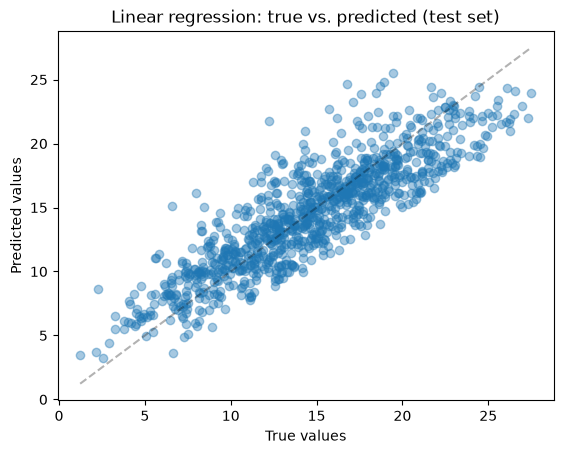

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=315)

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

train_predictions = lr_model.predict(X_train)
test_predictions = lr_model.predict(X_test)

train_rmse = root_mean_squared_error(y_train, train_predictions)
test_rmse = root_mean_squared_error(y_test, test_predictions)

print(f'Training RMSE: {train_rmse:.3f}')
print(f'Testing RMSE: {test_rmse:.3f}')

plt.scatter(y_test, test_predictions, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', alpha=0.3)
plt.xlabel('True values')
plt.ylabel('Predicted values')
plt.title('Linear regression: true vs. predicted (test set)')
plt.show()

results.append({'model': 'Linear regression', 'train_rmse': train_rmse, 'test_rmse': test_rmse})

## Task 2: Train and evaluate a decision tree model

**Tasks:**

1. Train a `DecisionTreeRegressor` on the training data from task 1.

2. Calculate and print the following metrics:
   - Training RMSE
   - Testing RMSE

3. Create a scatter plot of true vs. predicted values for the test set:
   - Add a diagonal reference line (y=x) to show perfect predictions
   - Label the axes appropriately
   - Add a title

**Hints:**

- Suggested hyperparameters: `DecisionTreeRegressor(max_depth=8, min_samples_split=30, min_samples_leaf=15, random_state=315)`
- Use the same `X_train`, `X_test`, `y_train`, `y_test` from task 1.
- You are encouraged to experiment with the hyperparameter values and observe how they affect training and testing RMSE.

Training RMSE: 1.720
Testing RMSE: 2.090


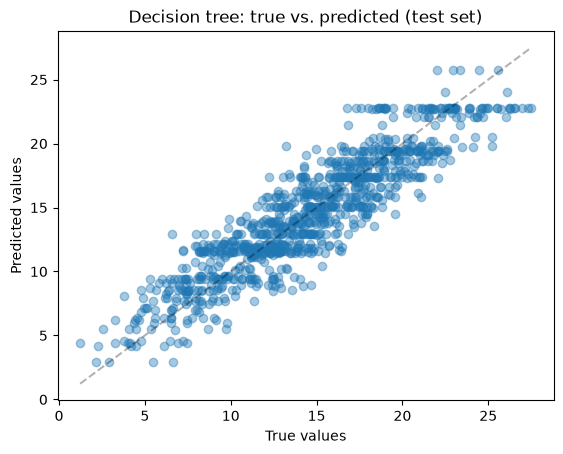

In [6]:
dt_model = DecisionTreeRegressor(max_depth=8, min_samples_split=30, min_samples_leaf=15, random_state=315)
dt_model.fit(X_train, y_train)

train_predictions = dt_model.predict(X_train)
test_predictions = dt_model.predict(X_test)

train_rmse = root_mean_squared_error(y_train, train_predictions)
test_rmse = root_mean_squared_error(y_test, test_predictions)

print(f'Training RMSE: {train_rmse:.3f}')
print(f'Testing RMSE: {test_rmse:.3f}')

plt.scatter(y_test, test_predictions, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', alpha=0.3)
plt.xlabel('True values')
plt.ylabel('Predicted values')
plt.title('Decision tree: true vs. predicted (test set)')
plt.show()

results.append({'model': 'Decision tree', 'train_rmse': train_rmse, 'test_rmse': test_rmse})

## Task 3: Train and evaluate a random forest model

**Tasks:**

1. Train a `RandomForestRegressor` on the training data from task 1.

2. Calculate and print the following metrics:
   - Training RMSE
   - Testing RMSE

3. Create a scatter plot of true vs. predicted values for the test set:
   - Add a diagonal reference line (y=x) to show perfect predictions
   - Label the axes appropriately
   - Add a title

**Hints:**

- A random forest trains an ensemble of decision trees and averages their predictions. This typically reduces the variance (overfitting) seen in a single tree.
- Suggested hyperparameters: `RandomForestRegressor(n_estimators=100, random_state=315)`
- Use the same `X_train`, `X_test`, `y_train`, `y_test` from task 1.
- You are encouraged to experiment with the hyperparameter values and observe how they affect training and testing RMSE.

Training RMSE: 0.430
Testing RMSE: 1.139


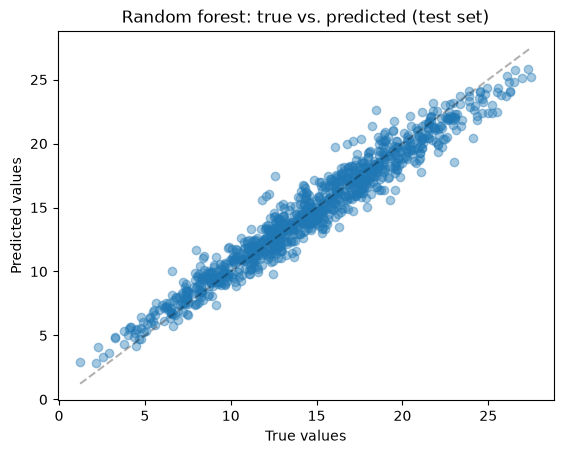

In [7]:
rf_model = RandomForestRegressor(random_state=315)
rf_model.fit(X_train, y_train)

train_predictions = rf_model.predict(X_train)
test_predictions = rf_model.predict(X_test)

train_rmse = root_mean_squared_error(y_train, train_predictions)
test_rmse = root_mean_squared_error(y_test, test_predictions)

print(f'Training RMSE: {train_rmse:.3f}')
print(f'Testing RMSE: {test_rmse:.3f}')

plt.scatter(y_test, test_predictions, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', alpha=0.3)
plt.xlabel('True values')
plt.ylabel('Predicted values')
plt.title('Random forest: true vs. predicted (test set)')
plt.show()

results.append({'model': 'Random forest', 'train_rmse': train_rmse, 'test_rmse': test_rmse})

## Task 4: Train and evaluate a k-nearest neighbors (KNN) model

**Tasks:**

1. Train a `KNeighborsRegressor` on the training data from task 1.

2. Calculate and print the following metrics:
   - Training RMSE
   - Testing RMSE

3. Create a scatter plot of true vs. predicted values for the test set.

**Hints:**

- KNN regression predicts the mean target value of the k nearest training points. There is no explicit training step: the training data is stored and queried at prediction time.
- Suggested hyperparameters: `KNeighborsRegressor(n_neighbors=10)`
- Use the same `X_train`, `X_test`, `y_train`, `y_test` from task 1.
- You are encouraged to experiment with different values of `n_neighbors` and observe how they affect training and testing RMSE.

Training RMSE: 0.915
Testing RMSE: 1.040


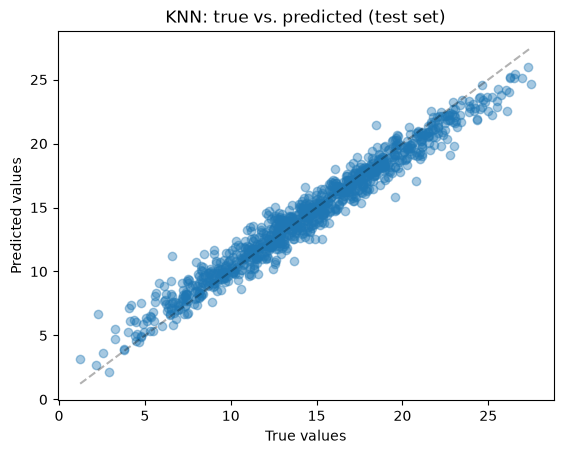

In [8]:
knn_model = KNeighborsRegressor(n_neighbors=10)
knn_model.fit(X_train, y_train)

train_predictions = knn_model.predict(X_train)
test_predictions = knn_model.predict(X_test)

train_rmse = root_mean_squared_error(y_train, train_predictions)
test_rmse = root_mean_squared_error(y_test, test_predictions)

print(f'Training RMSE: {train_rmse:.3f}')
print(f'Testing RMSE: {test_rmse:.3f}')

plt.scatter(y_test, test_predictions, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', alpha=0.3)
plt.xlabel('True values')
plt.ylabel('Predicted values')
plt.title('KNN: true vs. predicted (test set)')
plt.show()

results.append({'model': 'KNN', 'train_rmse': train_rmse, 'test_rmse': test_rmse})

## Task 5: Train and evaluate a support vector machine (SVR) model

**Tasks:**

1. Train an `SVR` model on the training data from task 1.

2. Calculate and print the following metrics:
   - Training RMSE
   - Testing RMSE

3. Create a scatter plot of true vs. predicted values for the test set.

**Hints:**

- SVR fits a tube of width epsilon around the training data and finds a hyperplane that maximizes the margin. The `C` parameter controls the trade-off between margin width and training error.
- Suggested hyperparameters: `SVR(kernel='rbf', C=10, epsilon=0.1)`
- Use the same `X_train`, `X_test`, `y_train`, `y_test` from task 1.
- You are encouraged to experiment with `C`, `epsilon`, and `kernel` and observe how they affect training and testing RMSE.

Training RMSE: 0.082
Testing RMSE: 0.103


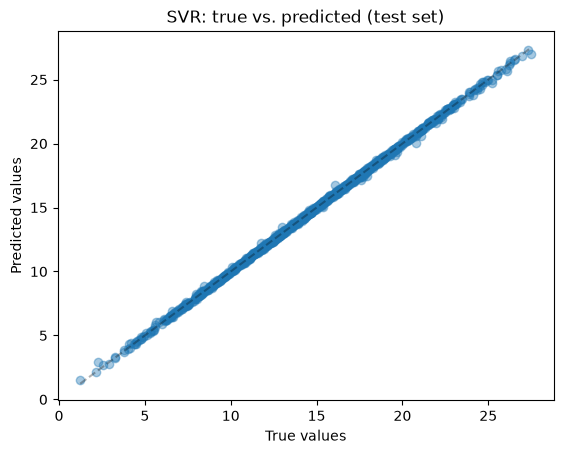

In [9]:
svr_model = SVR(kernel='rbf', C=10, epsilon=0.1)
svr_model.fit(X_train, y_train)

train_predictions = svr_model.predict(X_train)
test_predictions = svr_model.predict(X_test)

train_rmse = root_mean_squared_error(y_train, train_predictions)
test_rmse = root_mean_squared_error(y_test, test_predictions)

print(f'Training RMSE: {train_rmse:.3f}')
print(f'Testing RMSE: {test_rmse:.3f}')

plt.scatter(y_test, test_predictions, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', alpha=0.3)
plt.xlabel('True values')
plt.ylabel('Predicted values')
plt.title('SVR: true vs. predicted (test set)')
plt.show()

results.append({'model': 'SVR', 'train_rmse': train_rmse, 'test_rmse': test_rmse})

## Task 6: Train and evaluate a Gaussian process regression (GPR) model

**Tasks:**

1. Train a `GaussianProcessRegressor` on a subset of the training data.

2. Calculate and print the following metrics:
   - Training RMSE (on the training subset)
   - Testing RMSE (on the full test set)

3. Create a scatter plot of true vs. predicted values for the test set.

**Notes:**

- GPR scales as O(n³) due to matrix inversion, making it impractical on large datasets. Train on a 500-sample subset to keep runtime manageable.
- Unlike the other models, GPR also returns a standard deviation per prediction, which lets you quantify prediction uncertainty.

**Hints:**

- Use a subset of the training data: `X_train_sub, y_train_sub = X_train[:500], y_train[:500]`
- Suggested kernel: `kernel = 1.0 * RBF(length_scale=1.0) + WhiteKernel(noise_level=1.0)`
- Suggested model: `GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=2, random_state=315)`
- Predictions with uncertainty: `y_pred, y_std = gpr_model.predict(X_test, return_std=True)`
- Evaluate on the same `X_test`, `y_test` from task 1.
- You are encouraged to experiment with different kernels and `length_scale` values and observe how they affect the fit.

Training RMSE: 0.002
Testing RMSE: 0.046


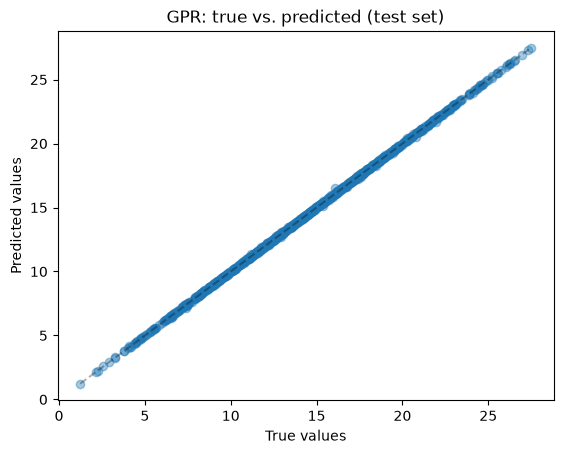

In [10]:
X_train_sub, y_train_sub = X_train[:500], y_train[:500]

kernel = 1.0 * RBF(length_scale=1.0) + WhiteKernel(noise_level=1.0)
gpr_model = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=2, random_state=315)
gpr_model.fit(X_train_sub, y_train_sub)

train_predictions = gpr_model.predict(X_train_sub)
test_predictions, test_std = gpr_model.predict(X_test, return_std=True)

train_rmse = root_mean_squared_error(y_train_sub, train_predictions)
test_rmse = root_mean_squared_error(y_test, test_predictions)

print(f'Training RMSE: {train_rmse:.3f}')
print(f'Testing RMSE: {test_rmse:.3f}')

plt.scatter(y_test, test_predictions, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', alpha=0.3)
plt.xlabel('True values')
plt.ylabel('Predicted values')
plt.title('GPR: true vs. predicted (test set)')
plt.show()

results.append({'model': 'GPR', 'train_rmse': train_rmse, 'test_rmse': test_rmse})

## Task 7: Compare model performance

**Tasks:**

1. Using the results you collected during tasks 1–6, create a horizontal bar chart of test RMSE for all six models, sorted from lowest to highest error.

2. Print a summary table with training RMSE and testing RMSE for all models.

3. Based on the results:
   - Which model achieves the lowest test RMSE?
   - Which models show the largest gap between training and testing RMSE? What does that indicate?
   - Is the best-performing model always the right choice? Consider factors like interpretability and training cost.

**Notes:**

- The GPR model was trained on only 500 samples, so its metrics are not directly comparable to the other models. Note this caveat when interpreting the results.

**Hints:**

- To create a sorted bar chart: sort the test RMSE values (and model names) together before plotting.

,model,train_rmse,test_rmse
5,GPR,0.002160,0.045730
4,SVR,0.081935,0.103012
3,KNN,0.914854,1.040376
2,Random forest,0.429677,1.138547
1,Decision tree,1.719722,2.090083
0,Linear regression,2.435933,2.442001


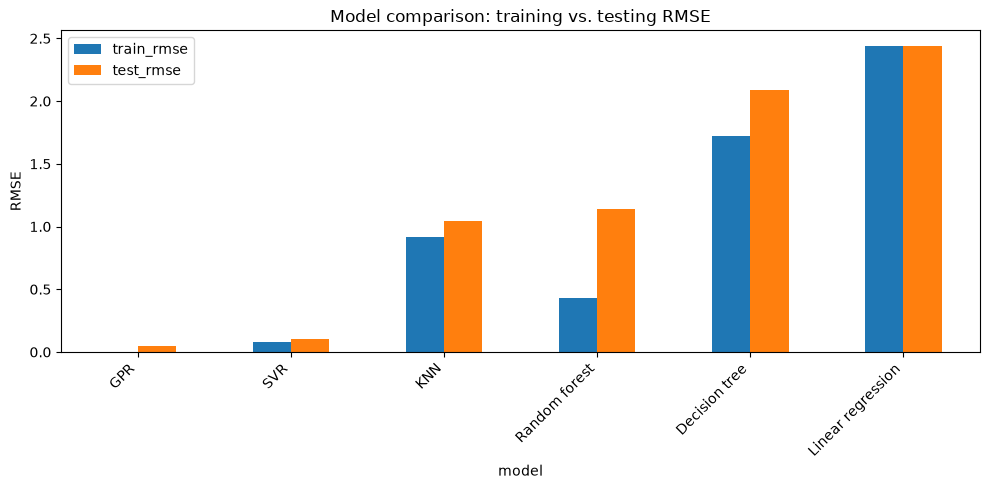

In [11]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('test_rmse')
display(results_df)

results_df.plot(x='model', y=['train_rmse', 'test_rmse'], kind='bar', figsize=(10, 5))
plt.ylabel('RMSE')
plt.title('Model comparison: training vs. testing RMSE')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Task 8: Investigate why the models perform differently

**Tasks:**

1. Create visualizations to understand the relationship between features and label:
   - For features 0 and 1: create a 2D scatter plot colored by the label value (use a colormap)
   - For features 2, 3, and 4: create individual scatter plots vs. label

2. Based on your plots:
   - Identify which relationships are linear
   - Identify which relationships are non-linear
   - Explain how this affects each model's performance

3. (Optional) Try to improve the linear regression model by adding polynomial features for the non-linear relationships. Does this improve performance?

**Hints:**

- For a 2D scatter plot with color mapping:
  - `plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis')`
  - `plt.colorbar(label='Label')`

- Tree-based models and KNN can capture non-linear relationships, while linear regression assumes linear structure. GPR can model arbitrary non-linear patterns via the kernel function.

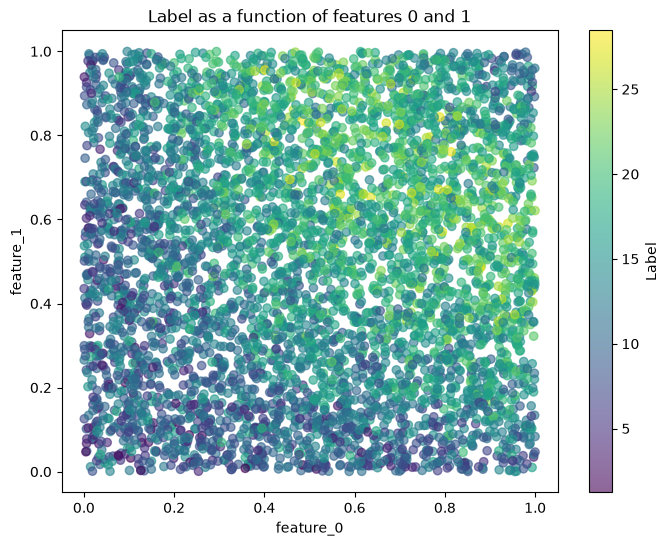

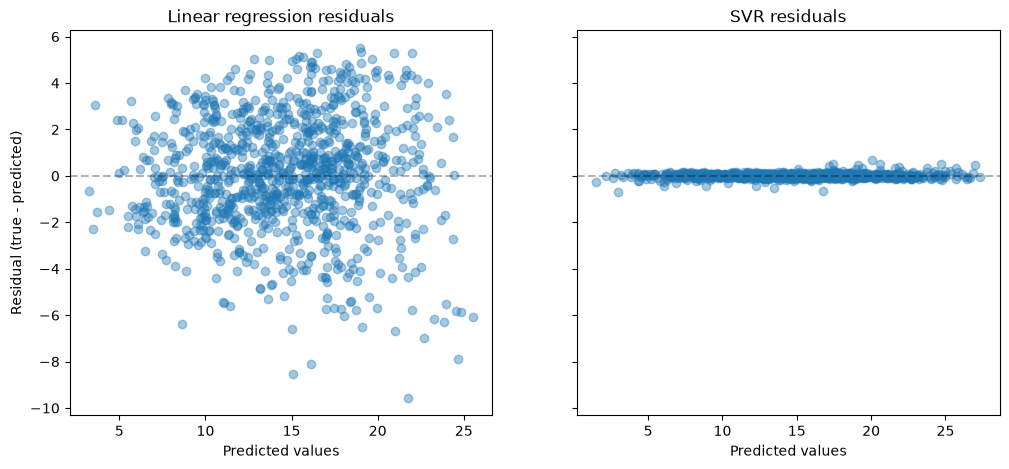

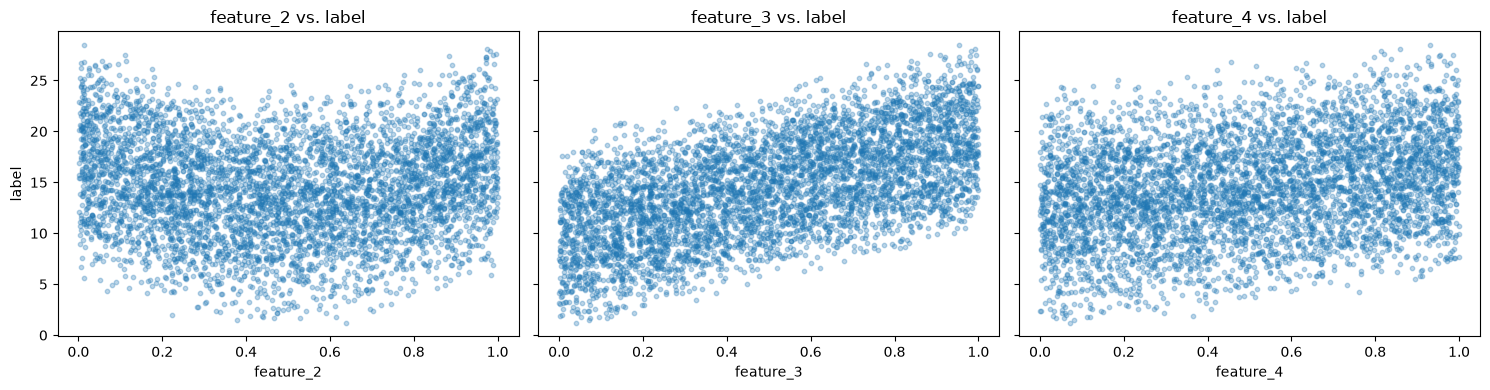

In [12]:
# The data's shape: features 0 and 1 colored by label
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', alpha=0.6)
plt.colorbar(label='Label')
plt.xlabel('feature_0')
plt.ylabel('feature_1')
plt.title('Label as a function of features 0 and 1')
plt.show()

# Residuals: structural error (linear regression) vs. matched model (SVR)
lr_residuals = y_test - lr_model.predict(X_test)
svr_residuals = y_test - svr_model.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
axes[0].scatter(lr_model.predict(X_test), lr_residuals, alpha=0.4)
axes[0].axhline(0, color='k', linestyle='--', alpha=0.3)
axes[0].set_xlabel('Predicted values')
axes[0].set_ylabel('Residual (true - predicted)')
axes[0].set_title('Linear regression residuals')

axes[1].scatter(svr_model.predict(X_test), svr_residuals, alpha=0.4)
axes[1].axhline(0, color='k', linestyle='--', alpha=0.3)
axes[1].set_xlabel('Predicted values')
axes[1].set_title('SVR residuals')
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for i, feature in enumerate([2, 3, 4]):
    axes[i].scatter(X[:, feature], y, alpha=0.3, s=10)
    axes[i].set_xlabel(f'feature_{feature}')
    axes[i].set_title(f'feature_{feature} vs. label')

axes[0].set_ylabel('label')
plt.tight_layout()
plt.show()

## Reflection

Based on your analysis, answer the following questions:

1. **Model performance**: Which model performed better and why?

2. **Linear assumptions**: What happens when you apply linear regression to non-linear data?

3. **Model complexity**: What are the trade-offs between simpler models (linear regression) and more complex models (decision trees)?

4. **Real-world implications**: In what situations would you prefer:
   - A linear regression model?
   - A decision tree model?
   - Something else?
   - Consider factors like interpretability, performance, and data characteristics.

## Reflection answers

1. **Model performance**: Gaussian process regression performed best with a test RMSE of 0.046, followed closely by SVR at 0.103. Both models beat the others by a wide margin, and they share the same advantage: their RBF kernels assume the target is a smooth, continuous function, and the Friedman1 target actually is one. GPR won despite training on only 500 samples, one eighth of what the other models received, because it also estimates the noise level in the data as part of training. Since this dataset was generated with no noise, GPR could interpolate the underlying function almost exactly. The general lesson is that models win when their built-in assumptions match the process that generated the data, not because any model family is universally superior.

2. **Linear assumptions**: Applying linear regression to non-linear data causes underfitting. Linear regression can only represent the target as a weighted sum of the features, which is a flat plane, and no plane can trace the curvature created by the sine interaction and squared term in the Friedman1 formula. The signature showed up in two places. First, training RMSE (2.436) and testing RMSE (2.442) were high and nearly identical, meaning the model was equally wrong on data it had seen and data it had not. There was nothing to memorize because the model lacked the capacity to fit the shape at all. Second, the residual plot showed visible structure rather than random scatter, with errors drifting systematically across the prediction range. Structured residuals mean the curvature the model could not express leaked into the leftovers.

3. **Model complexity**: Simpler models are stable, fast, and interpretable, but they can miss real structure, which is what happened to linear regression here. More complex models can capture that structure but risk fitting noise, which is overfitting. My decision tree experiment complicated the usual story, though. The unregularized tree memorized the training data perfectly (train RMSE 0.000) and still scored 1.880 on the test set, while the regularized tree with `max_depth=8` and leaf constraints closed the train/test gap (1.720 vs 2.090) but performed worse on the test set. That happened because this dataset is noiseless, so the memorization was capturing pure signal and there was no noise for regularization to protect against. The constraints only blurred a function the tree was allowed to learn exactly. The takeaway is that complexity is a liability in proportion to how noisy the data is, and regularization is a trade-off to be tested, not a virtue to be applied automatically.

4. **Real-world implications**: I would prefer linear regression when interpretability matters most, when I need to explain exactly how each feature affects the prediction, when data is limited, or when the relationship is genuinely close to linear. It is also fast enough to serve as a baseline for any regression problem. I would prefer a decision tree when the data has interactions and mixed feature types and stakeholders need a model they can read as a set of rules, keeping in mind that a single tree is unstable and usually loses to an ensemble. For raw predictive performance on messy real-world tabular data, I would reach for a random forest or gradient boosting, since averaging many trees handles noise and scales to large datasets. I would choose SVR when I expect a smooth underlying process and have a moderate amount of data, remembering that it needs feature scaling in most real datasets. I would choose GPR when the dataset is small, I expect smoothness, and I need uncertainty estimates alongside predictions, for example in engineering or process modeling where knowing how confident the model is matters as much as the prediction itself. Its O(n³) training cost rules it out for large datasets.

## Extra: hyperparameter tuning for class discussion

In [13]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [4, 8, 12, 16, 20, None],
    'min_samples_split': [2, 10, 30],
    'min_samples_leaf': [1, 5, 15]
}

grid_search = GridSearchCV(
    DecisionTreeRegressor(random_state=315),
    param_grid,
    cv=3,
    scoring='neg_root_mean_squared_error'
)

grid_search.fit(X_train, y_train)

print('Best parameters:', grid_search.best_params_)
print(f'Best CV RMSE: {-grid_search.best_score_:.3f}')

best_tree = grid_search.best_estimator_
tuned_test_rmse = root_mean_squared_error(y_test, best_tree.predict(X_test))
print(f'Tuned test RMSE: {tuned_test_rmse:.3f}')

Best parameters: {'max_depth': 20, 'min_samples_leaf': 5, 'min_samples_split': 2}
Best CV RMSE: 1.998
Tuned test RMSE: 1.772
